# Reusable Template: Multivariate Time Series Project

A parametrized starting point for a new cross-correlation / ARIMAX / VAR
project. Fill in the **CONFIG** cell, then run top to bottom. Sections are
independent enough that you can skip ARIMAX or VAR entirely depending on
your problem (single target with helper covariates -> ARIMAX; a small
system where every variable matters -> VAR).

**How to reuse this:**
1. Point `DATA_PATH` (or the loader function) at your own data, or replace
   `load_data()` with your own ingestion code — must return a wide
   DataFrame, one column per series, sorted by time, evenly spaced.
2. Set `TARGET_COL` (your forecast target) and `CANDIDATE_EXOG_COLS`.
3. Run the notebook. Read the printed diagnostics before trusting output —
   this template does *not* silently pick good settings for you.


## 0. Config

In [1]:
# ---- CONFIG: EDIT THIS CELL FOR YOUR PROJECT ----
DATA_PATH = None                 # e.g. "my_data.csv"; leave None to use the demo generator below
TARGET_COL = "y"                 # column you want to forecast (used for ARIMAX)
CANDIDATE_EXOG_COLS = ["x1", "x2"]   # candidate covariates to screen via CCF (ARIMAX section)
VAR_COLS = ["y", "x1", "x2"]     # columns to include in the VAR system (VAR section)
MAX_LAG = 40                     # how many lags to check in CCF / PACF plots
SIG_LEVEL = 95                   # 90 / 95 / 99, for the CCF significance band
TEST_FRACTION = 0.2              # holdout fraction for forecast evaluation
FREQ_LABEL = "step"              # just for axis labels, e.g. "hour", "quarter"
RANDOM_SEED = 42
# --------------------------------------------------


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.signal import correlate
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error

pd.options.display.float_format = "{:.4f}".format

## 1. Load data

In [3]:
def load_data():
    """Replace this with real ingestion (pd.read_csv, a DB query, etc).
    Must return a DataFrame indexed 0..n-1 (or a DatetimeIndex), one column
    per series, no gaps."""
    if DATA_PATH is not None:
        return pd.read_csv(DATA_PATH)

    # --- demo fallback: small synthetic multivariate series ---
    rng = np.random.default_rng(RANDOM_SEED)
    n = 500
    x1 = pd.Series(rng.normal(size=n)).rolling(4, min_periods=1).mean()
    x2 = pd.Series(rng.normal(size=n)).rolling(6, min_periods=1).mean()
    y = 0.5 * x1.shift(5).fillna(0) + 0.3 * x2.shift(10).fillna(0) + rng.normal(scale=0.5, size=n)
    return pd.DataFrame({"y": y, "x1": x1, "x2": x2})

df = load_data()
print(df.shape)
df.head()

(500, 3)


,y,x1,x2
0,-0.0296,0.3047,1.3639
1,-0.3646,-0.3676,1.1295
2,-0.2072,0.0051,0.5132
3,0.3170,0.2389,0.0093
4,0.0015,-0.3250,-0.5855


## 2. Visual inspection & stationarity

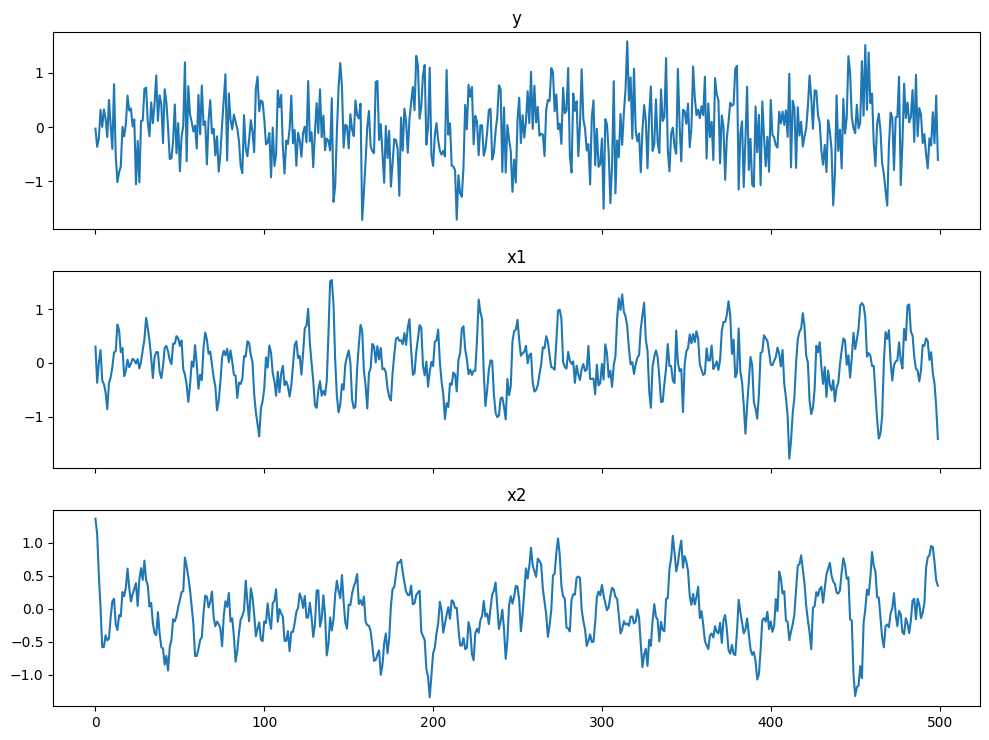

In [4]:
fig, axes = plt.subplots(len(df.columns), 1, figsize=(10, 2.5 * len(df.columns)), sharex=True)
if len(df.columns) == 1:
    axes = [axes]
for ax, col in zip(axes, df.columns):
    ax.plot(df[col].values)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [5]:
def adf_report(series, name=""):
    stat, pval, *_ = adfuller(series.dropna(), autolag="AIC")
    verdict = "stationary" if pval < 0.05 else "NON-stationary (consider differencing)"
    print(f"{name:>15s}: ADF stat={stat:8.3f}  p={pval:.4f}  -> {verdict}")
    return pval

adf_pvals = {c: adf_report(df[c], c) for c in df.columns}

              y: ADF stat= -12.112  p=0.0000  -> stationary
             x1: ADF stat=  -5.825  p=0.0000  -> stationary
             x2: ADF stat=  -4.333  p=0.0004  -> stationary


/tmp/ipykernel_658/2420564415.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval, *_ = adfuller(series.dropna(), autolag="AIC")
/tmp/ipykernel_658/2420564415.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval, *_ = adfuller(series.dropna(), autolag="AIC")
/tmp/ipykernel_658/2420564415.py:2: FutureWarning: adfuller currently returns a plain tuple wh

In [6]:
# If any series is non-stationary, difference it here.
# Keep a copy of the levels (df) separate from the differenced working frame (df_d)
# so you can reconstruct forecasts back to levels later if needed.
NEEDS_DIFF = [c for c, p in adf_pvals.items() if p >= 0.05]
print("Columns flagged for differencing:", NEEDS_DIFF)

df_d = df.copy()
for c in NEEDS_DIFF:
    df_d[c] = df_d[c].diff()
df_d = df_d.dropna().reset_index(drop=True)

for c in NEEDS_DIFF:
    adf_report(df_d[c], f"{c} (diff)")

Columns flagged for differencing: []


## 3. Cross-correlation screening

In [7]:
def plot_ccf(data_a, data_b, lag_lookback, percentile=95, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3.5))
    n = len(data_a)
    ccf = correlate(data_a - np.mean(data_a), data_b - np.mean(data_b),
                     method="direct") / (np.std(data_a) * np.std(data_b) * n)
    mid = (len(ccf) - 1) // 2
    lags = np.arange(-lag_lookback, lag_lookback)
    vals = ccf[mid - lag_lookback: mid + lag_lookback]
    z = {90: 1.645, 95: 1.96, 99: 2.576}[percentile]
    band = z / np.sqrt(n)
    ax.stem(lags, vals, markerfmt="o")
    ax.axhline(band, color="b", ls="--"); ax.axhline(-band, color="b", ls="--")
    ax.axvline(0, color="black")
    ax.set_xlabel(f"Lag ({FREQ_LABEL}s)"); ax.set_ylabel("Correlation"); ax.set_title(title)
    return lags, vals, band

def significant_lags(data_a, data_b, lag_lookback, percentile=95):
    lags, vals, band = plot_ccf(data_a, data_b, lag_lookback, percentile,
                                 ax=plt.subplots(figsize=(0.1, 0.1))[1])
    plt.close()
    sig = lags[(np.abs(vals) > band) & (lags > 0)]  # keep only lags usable for forecasting (>0)
    return sig.tolist()

x1: significant positive lags -> [2, 3, 4, 5, 6, 7, 13, 14, 16, 18, 19, 34]
x2: significant positive lags -> [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 25, 32, 33, 34, 35]


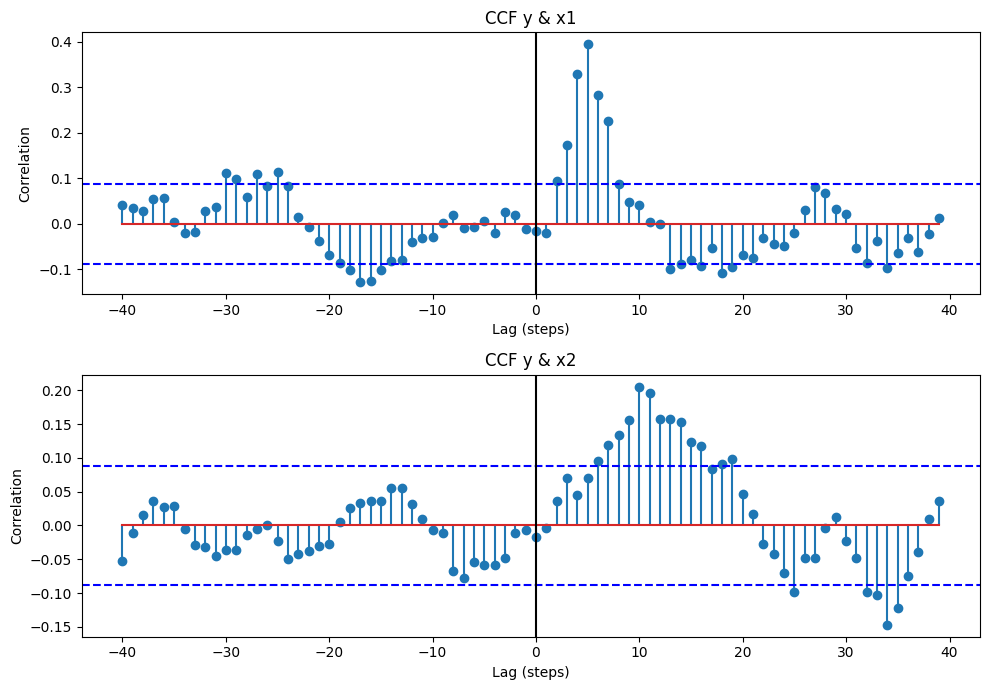

In [8]:
exog_sig_lags = {}
fig, axes = plt.subplots(len(CANDIDATE_EXOG_COLS), 1,
                          figsize=(10, 3.5 * len(CANDIDATE_EXOG_COLS)))
if len(CANDIDATE_EXOG_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, CANDIDATE_EXOG_COLS):
    lags, vals, band = plot_ccf(df_d[TARGET_COL], df_d[col], MAX_LAG, SIG_LEVEL, ax=ax,
                                 title=f"CCF {TARGET_COL} & {col}")
    sig = lags[(np.abs(vals) > band) & (lags > 0)]
    exog_sig_lags[col] = sig.tolist()
    print(f"{col}: significant positive lags -> {sig.tolist()}")
plt.tight_layout(); plt.show()

## 4. ARIMAX: build lagged exogenous matrix & fit

In [9]:
def build_lag_matrix(df, lag_map):
    """lag_map: {column_name: [lag1, lag2, ...]} -> DataFrame of shifted columns."""
    cols = {}
    for col, lags in lag_map.items():
        for lag in lags:
            cols[f"{col}_lag{lag}"] = df[col].shift(-lag)
    return pd.DataFrame(cols)

# Cap the number of lags per variable to avoid multicollinearity explosion (edit as needed)
MAX_LAGS_PER_VAR = 3
trimmed_lag_map = {c: sorted(l, key=lambda x: -abs(x))[:MAX_LAGS_PER_VAR] if False else l[:MAX_LAGS_PER_VAR]
                    for c, l in exog_sig_lags.items() if l}

X_full = build_lag_matrix(df_d, trimmed_lag_map).dropna()
y_full = df_d[TARGET_COL].loc[X_full.index]
print(X_full.shape)
X_full.head()

(492, 6)


,x1_lag2,x1_lag3,x1_lag4,x2_lag6,x2_lag7,x2_lag8
0,0.0051,0.2389,-0.3250,-0.4024,-0.4791,-0.4525
1,0.2389,-0.3250,-0.3905,-0.4791,-0.4525,-0.1245
2,-0.3250,-0.3905,-0.5462,-0.4525,-0.1245,0.1094
3,-0.3905,-0.5462,-0.8604,-0.1245,0.1094,0.1504
4,-0.5462,-0.8604,-0.3768,0.1094,0.1504,-0.2364


In [10]:
split = int(len(y_full) * (1 - TEST_FRACTION))
y_train, y_test = y_full.iloc[:split], y_full.iloc[split:]
X_train, X_test = X_full.iloc[:split], X_full.iloc[split:]

def vif_table(X):
    Xc = sm.add_constant(X)
    return pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=X.columns, name="VIF"
    ).sort_values(ascending=False)

print("VIF (values > ~10 suggest problematic collinearity):")
vif_table(X_train) if X_train.shape[1] else "No exogenous columns selected."

VIF (values > ~10 suggest problematic collinearity):


x2_lag7   6.7461
x1_lag3   4.4827
x2_lag6   3.5343
x2_lag8   3.5275
x1_lag4   2.4532
x1_lag2   2.4521
Name: VIF, dtype: float64

In [11]:
if X_train.shape[1] > 0:
    arimax_model = SARIMAX(y_train, exog=X_train, order=(1, 0, 0),
                            enforce_stationarity=True, enforce_invertibility=True)
    arimax_fit = arimax_model.fit(disp=False)

    # simple iterative p-value pruning
    pvals = arimax_fit.pvalues.filter(items=X_train.columns)
    X_sel = X_train.copy()
    while len(pvals) and (pvals > 0.05).any():
        drop_col = pvals.idxmax()
        X_sel = X_sel.drop(columns=[drop_col])
        if X_sel.shape[1] == 0:
            arimax_model = SARIMAX(y_train, order=(1, 0, 0))
            arimax_fit = arimax_model.fit(disp=False)
            break
        arimax_model = SARIMAX(y_train, exog=X_sel, order=(1, 0, 0),
                                enforce_stationarity=True, enforce_invertibility=True)
        arimax_fit = arimax_model.fit(disp=False)
        pvals = arimax_fit.pvalues.filter(items=X_sel.columns)
    print(arimax_fit.summary())
else:
    print("No significant exogenous lags found; fit a plain ARIMA baseline instead.")
    arimax_model = SARIMAX(y_train, order=(1, 0, 0))
    arimax_fit = arimax_model.fit(disp=False)
    X_sel = X_train

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  393
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -331.951
Date:                Sat, 29 Aug 2026   AIC                            667.902
Time:                        01:55:38   BIC                            675.850
Sample:                             0   HQIC                           671.052
                                - 393                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2263      0.048      4.711      0.000       0.132       0.320
sigma2         0.3170      0.023     13.515      0.000       0.271       0.363
Ljung-Box (L1) (Q):                   0.23   Jarque-

All exogenous terms were pruned; ARIMAX reduces to the baseline model here.


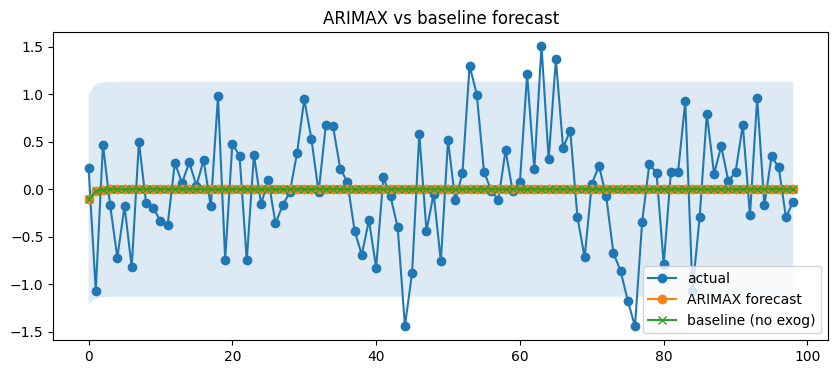

ARIMAX MSE:   0.3506271130843102
Baseline MSE: 0.3506271130843102


In [12]:
baseline_model = SARIMAX(y_train, order=(1, 0, 0))
baseline_fit = baseline_model.fit(disp=False)

exog_test = X_test[X_sel.columns] if X_sel.shape[1] else None
if X_sel.shape[1] == 0:
    print("All exogenous terms were pruned; ARIMAX reduces to the baseline model here.")
fc = arimax_fit.get_forecast(steps=len(y_test), exog=exog_test)
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

fc_base = baseline_fit.get_forecast(steps=len(y_test))
pred_base = fc_base.predicted_mean

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test.values, marker="o", label="actual")
ax.plot(pred.values, marker="o", label="ARIMAX forecast")
ax.plot(pred_base.values, marker="x", label="baseline (no exog)")
ax.fill_between(range(len(pred)), ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.15)
ax.legend(); ax.set_title("ARIMAX vs baseline forecast")
plt.show()

print("ARIMAX MSE:  ", mean_squared_error(y_test, pred))
print("Baseline MSE:", mean_squared_error(y_test, pred_base))

## 5. VAR: system-wide model across `VAR_COLS`

In [13]:
var_data = df_d[VAR_COLS].dropna().reset_index(drop=True)

best_aic, best_order = np.inf, None
for p in range(1, 5):
    for q in range(0, 2):
        try:
            m = VARMAX(var_data, order=(p, q), trend="c",
                       enforce_stationarity=True, enforce_invertibility=True)
            r = m.fit(disp=False)
            if r.aic < best_aic:
                best_aic, best_order = r.aic, (p, q)
        except Exception:
            continue
print("Selected VAR order (p, q) by AIC:", best_order)

var_model = VARMAX(var_data, order=best_order, trend="c",
                    enforce_stationarity=True, enforce_invertibility=True)
var_fit = var_model.fit(disp=False)
print(var_fit.summary())

/tmp/ipykernel_658/2119126007.py:7: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend="c",


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/tmp/ipykernel_658/2119126007.py:7: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend="c",


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/tmp/ipykernel_658/2119126007.py:7: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend="c",


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_658/2119126007.py:7: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend="c",


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_658/2119126007.py:16: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  var_model = VARMAX(var_data, order=best_order, trend="c",


Selected VAR order (p, q) by AIC: (4, 1)


                           Statespace Model Results                           
Dep. Variable:      ['y', 'x1', 'x2']   No. Observations:                  500
Model:                     VARMA(4,1)   Log Likelihood                -400.569
                          + intercept   AIC                            909.138
Date:                Sat, 29 Aug 2026   BIC                           1136.727
Time:                        01:55:59   HQIC                           998.444
Sample:                             0                                         
                                - 500                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):       0.79, 1.23, 0.17   Jarque-Bera (JB):     0.73, 2.89, 0.25
Prob(Q):                  0.37, 0.27, 0.68   Prob(JB):             0.70, 0.24, 0.88
Heteroskedasticity (H):   1.17, 1.31, 1.05   Skew:                -0.01, 0.19, 0.01
Prob(H) (two-sided):      0.31, 0.08,

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/tmp/ipykernel_658/2531959666.py:4: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  var_model_tr = VARMAX(train_v, order=best_order, trend="c",


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


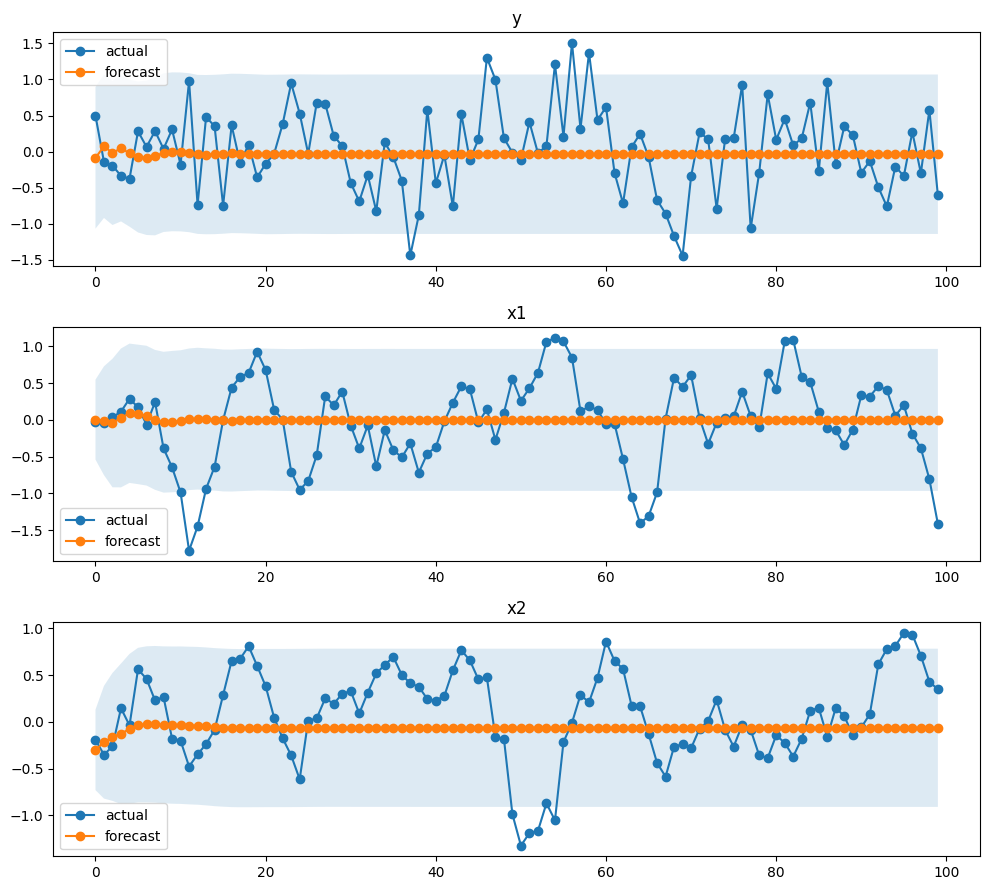

In [14]:
split_v = int(len(var_data) * (1 - TEST_FRACTION))
train_v, test_v = var_data.iloc[:split_v], var_data.iloc[split_v:]

var_model_tr = VARMAX(train_v, order=best_order, trend="c",
                       enforce_stationarity=True, enforce_invertibility=True)
var_fit_tr = var_model_tr.fit(disp=False)

fc_v_obj = var_fit_tr.get_forecast(steps=len(test_v))
fc_mean = fc_v_obj.predicted_mean          # one column per variable in VAR_COLS
fc_ci = fc_v_obj.conf_int(alpha=0.05)      # columns: "lower <var>", "upper <var>"

fig, axes = plt.subplots(len(VAR_COLS), 1, figsize=(10, 3 * len(VAR_COLS)))
if len(VAR_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, VAR_COLS):
    ax.plot(test_v[col].values, marker="o", label="actual")
    ax.plot(fc_mean[col].values, marker="o", label="forecast")
    ax.fill_between(range(len(test_v)), fc_ci[f"lower {col}"], fc_ci[f"upper {col}"], alpha=0.15)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 6. Granger causality & impulse responses (system diagnostics)

In [15]:
for col in VAR_COLS:
    if col == TARGET_COL:
        continue
    print(f"--- Does {col} Granger-cause {TARGET_COL}? ---")
    try:
        grangercausalitytests(var_data[[TARGET_COL, col]], maxlag=4)
    except Exception as e:
        print("skipped:", e)

--- Does x1 Granger-cause y? ---
--- Does x2 Granger-cause y? ---


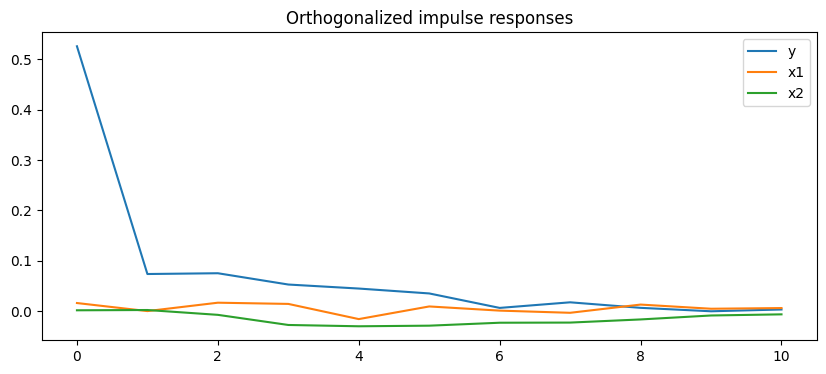

In [16]:
irf = var_fit.impulse_responses(steps=10, orthogonalized=True)
irf.plot(figsize=(10, 4), title="Orthogonalized impulse responses")
plt.show()

## 7. Next steps checklist

- [ ] Re-check ADF results after any differencing — confirm stationarity before trusting the model.
- [ ] If VIF flagged high multicollinearity, drop or combine lagged exogenous columns.
- [ ] Compare ARIMAX MSE against the no-exog baseline — only keep exogenous terms that clearly help out-of-sample.
- [ ] For VAR, check the error-covariance matrix in the summary for unexplained contemporaneous co-movement.
- [ ] If any series looked cointegrated (trending together) rather than just correlated, look into a VECM instead of differencing + VAR.
- [ ] Re-run with a rolling-origin backtest instead of a single train/test split before reporting a final error estimate.
